# Heart Disease Prediction using Machine Learning
## Exploratory Data Analysis (EDA)

### Dataset
Heart Disease UCI Dataset (Processed Cleveland)

### Objective
The objective of this notebook is to load, clean, preprocess, and analyze the Heart Disease dataset before building machine learning models.

In [1]:
# ===============================
# Import Required Libraries
# ===============================

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

In [ ]:
#Load Dataset
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    "../data/raw/processed.cleveland.data",
    names=column_names
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (303, 14)


In [7]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [12]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Data Cleaning

The original UCI Heart Disease dataset represents missing values using the character `?` instead of `NaN`. These values must be converted into `NaN` so that they can be properly identified and handled during preprocessing.

In [14]:
# Replace '?' with NaN

df.replace("?", np.nan, inplace=True)

print("All '?' values have been replaced with NaN.")

All '?' values have been replaced with NaN.


In [15]:
# Missing Values After Replacement

print("Missing Values After Replacing '?' with NaN:\n")

print(df.isnull().sum())

Missing Values After Replacing '?' with NaN:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


### Observation

After replacing `?` with `NaN`, missing values are detected in the `ca` and `thal` columns. These missing values will be handled before model training to ensure data quality and reliable predictions.

In [16]:
# Check Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    object 
 12  thal      301 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [17]:
# Convert Object Columns to Numeric

df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

print("Columns converted to numeric successfully.")

Columns converted to numeric successfully.


In [18]:
# Verify Updated Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [19]:
# Fill Missing Values

df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values handled successfully.")

Missing values handled successfully.


In [20]:
# Final Missing Value Check

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### Observation

All missing values have been successfully handled by replacing them with the median of their respective columns. Since the dataset contains only a few missing values, median imputation preserves the data distribution while avoiding unnecessary loss of records.

## Target Variable Transformation

The original UCI Heart Disease dataset contains five target classes:

- 0 → No heart disease
- 1–4 → Presence of heart disease with different severity levels

Since our project aims to build a **binary classification model**, all values greater than 0 are converted to **1**, representing the presence of heart disease.

In [21]:
# Original Target Distribution

print("Original Target Values:\n")
print(df["target"].value_counts().sort_index())

Original Target Values:

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [22]:
# Convert Target to Binary

df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

print("Target variable converted successfully.")

Target variable converted successfully.


In [23]:
# Verify Binary Target

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


### Observation

The target variable has been successfully converted into a binary classification problem:

- 0 → No Heart Disease
- 1 → Heart Disease

This format is suitable for training binary classification models such as Logistic Regression, Random Forest, and XGBoost.

In [31]:
# Save Cleaned Dataset

import os

# Create processed folder if it doesn't exist
os.makedirs("C:/Projects/Heart-Disease-MLOps/data/processed", exist_ok=True)

# Save cleaned dataset
df.to_csv("C:/Projects/Heart-Disease-MLOps/data/processed/heart.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Saved at: C:\Projects\Heart-Disease-MLOps\data\processed/heart.csv")

Cleaned dataset saved successfully!
Saved at: C:\Projects\Heart-Disease-MLOps\data\processed/heart.csv


In [33]:
# Verify Saved Dataset

heart_df = pd.read_csv("C:/Projects/Heart-Disease-MLOps/data/processed/heart.csv")

heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Observation

The cleaned dataset has been successfully saved and reloaded from the processed folder. This confirms that the preprocessing pipeline has executed correctly and the dataset is ready for further analysis.

In [34]:
# Final Dataset Information

heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [35]:
# Final Missing Value Check

heart_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [36]:
# Statistical Summary

heart_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [37]:
# Random Sample Records

heart_df.sample(10, random_state=42)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
179,53.0,1.0,3.0,130.0,246.0,1.0,2.0,173.0,0.0,0.0,1.0,3.0,3.0,0
228,54.0,1.0,4.0,110.0,206.0,0.0,2.0,108.0,1.0,0.0,2.0,1.0,3.0,1
111,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0,1
246,58.0,1.0,4.0,100.0,234.0,0.0,0.0,156.0,0.0,0.1,1.0,1.0,7.0,1
60,51.0,0.0,4.0,130.0,305.0,0.0,0.0,142.0,1.0,1.2,2.0,0.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1
119,65.0,1.0,4.0,135.0,254.0,0.0,2.0,127.0,0.0,2.8,2.0,1.0,7.0,1
223,53.0,1.0,4.0,123.0,282.0,0.0,0.0,95.0,1.0,2.0,2.0,2.0,7.0,1
268,40.0,1.0,4.0,152.0,223.0,0.0,0.0,181.0,0.0,0.0,1.0,0.0,7.0,1
33,59.0,1.0,4.0,135.0,234.0,0.0,0.0,161.0,0.0,0.5,2.0,0.0,7.0,0


### Observation

The dataset is now completely clean with all features converted to appropriate numeric data types. Missing values have been handled, and the target variable has been transformed into a binary classification label suitable for machine learning.

In [38]:
# Final Dataset Shape

print("Number of Rows :", heart_df.shape[0])
print("Number of Columns :", heart_df.shape[1])

Number of Rows : 303
Number of Columns : 14


# Data Preprocessing Summary

The preprocessing phase has been successfully completed.

### Steps Performed

- Loaded the Heart Disease dataset from the UCI repository.
- Assigned descriptive column names.
- Replaced missing value indicators (`"?"`) with `NaN`.
- Converted object columns (`ca` and `thal`) into numeric data types.
- Imputed missing values using the median.
- Converted the target variable into a binary classification label.
- Saved the cleaned dataset for future model development.

The dataset is now fully prepared for Exploratory Data Analysis (EDA) and machine learning model training.

In [2]:
# Create folder to save figures
os.makedirs("C:/Projects/Heart-Disease-MLOps/reports/figures", exist_ok=True)

# Load cleaned dataset
heart_df = pd.read_csv("C:/Projects/Heart-Disease-MLOps/data/processed/heart.csv")

heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Class Distribution Analysis

The class distribution plot shows the number of patients with and without heart disease. This visualization helps identify whether the dataset is balanced or imbalanced before training machine learning models.

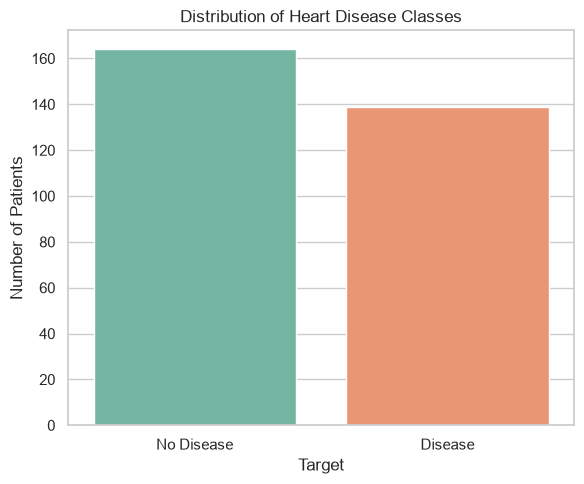

In [6]:
# Class Distribution

plt.figure(figsize=(6,5))

sns.countplot(
    data=heart_df,
    x="target",
    palette="Set2"
)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.xticks([0,1],["No Disease","Disease"])

plt.tight_layout()

plt.savefig("C:/Projects/Heart-Disease-MLOps/reports/figures/class_distribution.png", dpi=300)

plt.show()

### Observation

The dataset is relatively balanced, with slightly more patients belonging to the **No Heart Disease** class than the **Heart Disease** class. Since the class imbalance is minimal, standard classification algorithms can be trained without requiring major balancing techniques.

# Feature Distribution

Histograms are used to visualize the distribution of numerical features. They help identify skewness, spread, and possible outliers within each variable.

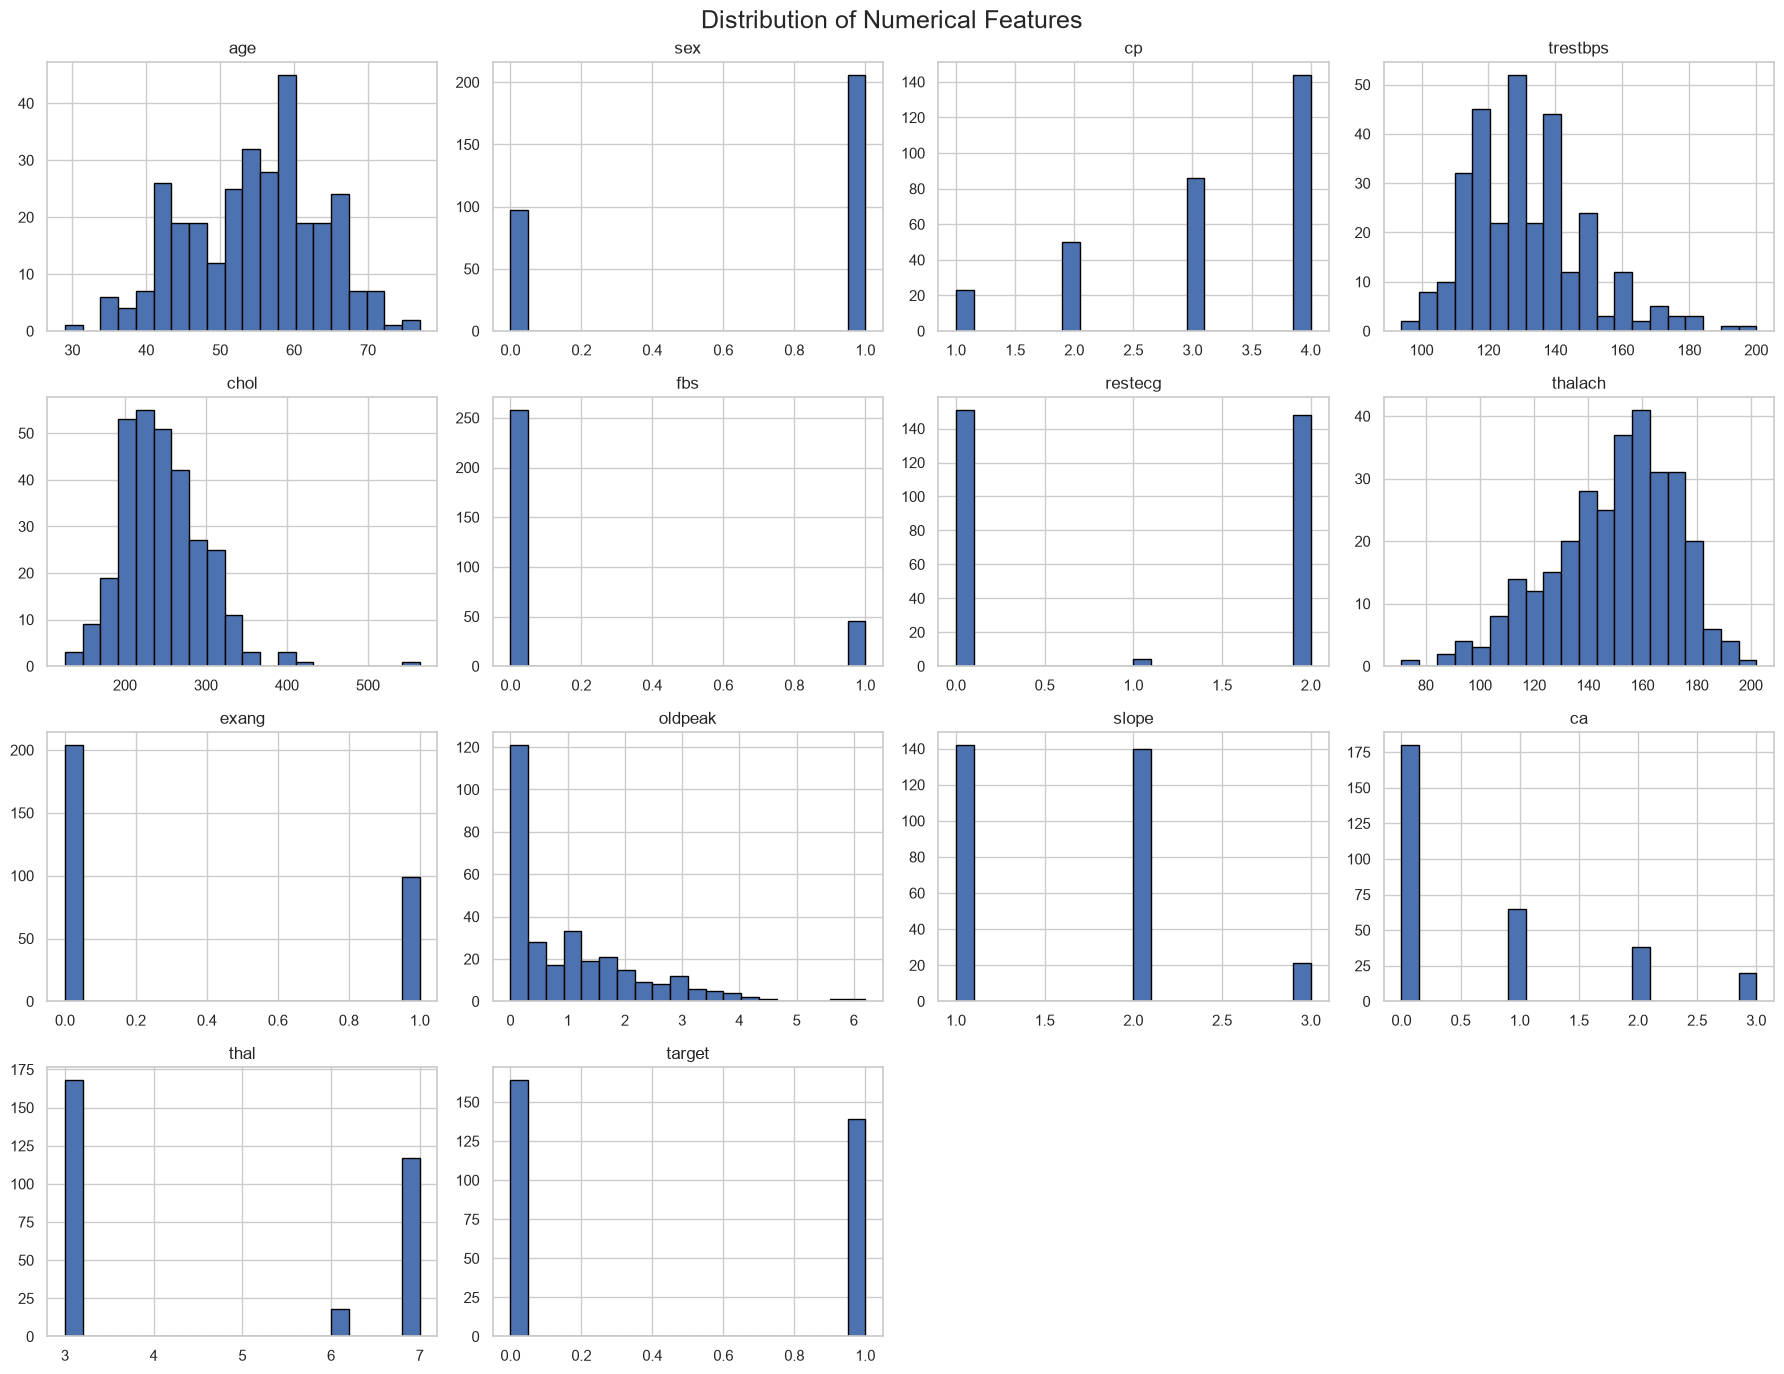

In [10]:
# Histograms

heart_df.hist(
    figsize=(18,14),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.savefig("C:/Projects/Heart-Disease-MLOps/reports/figures/histograms.png", dpi=300)

plt.show()

### Observation

The histograms indicate that several variables, such as **age**, **cholesterol**, and **maximum heart rate (thalach)**, follow approximately normal distributions. Some features are categorical or binary in nature and therefore display discrete distributions. These visualizations provide an initial understanding of the range and variability of each feature.

# Outlier Detection using Boxplots

Boxplots help identify potential outliers in numerical features. Outliers may influence model performance and should be examined before training.

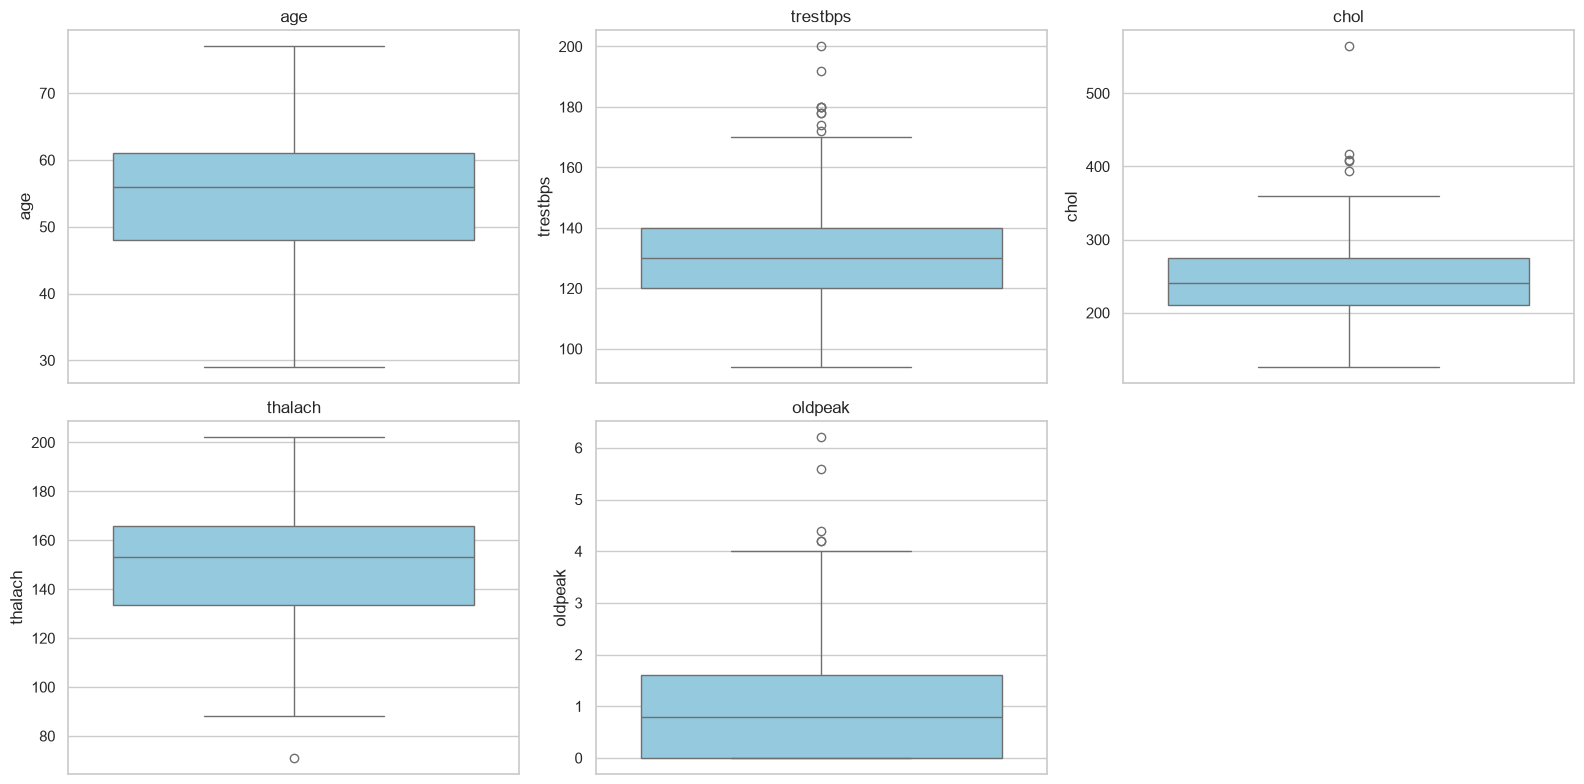

In [12]:
# Boxplots

numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

plt.figure(figsize=(16,8))

for i, col in enumerate(numerical_columns,1):

    plt.subplot(2,3,i)

    sns.boxplot(
        y=heart_df[col],
        color="skyblue"
    )

    plt.title(col)

plt.tight_layout()

plt.savefig("C:/Projects/Heart-Disease-MLOps/reports/figures/boxplots.png", dpi=300)

plt.show()

### Observation

The boxplots reveal that **cholesterol**, **resting blood pressure**, and **oldpeak** contain several outliers. These values may represent genuine clinical observations rather than measurement errors, so they are retained for model development.

# Correlation Heatmap

A correlation heatmap visualizes the relationship between numerical features using correlation coefficients. It helps identify positively and negatively correlated variables, which can be useful during feature selection and model interpretation.

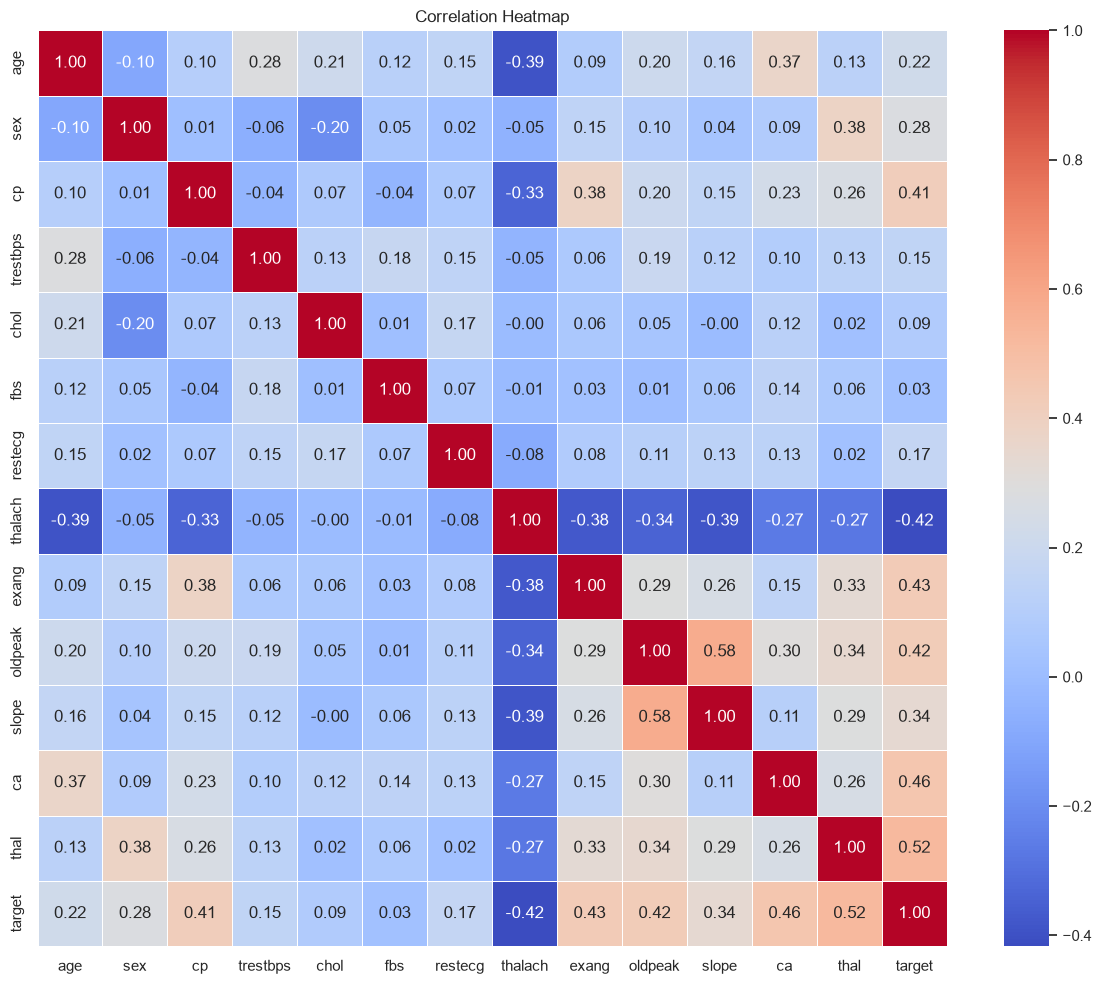

In [13]:
# Correlation Heatmap

plt.figure(figsize=(12,10))

correlation = heart_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("C:/Projects/Heart-Disease-MLOps/reports/figures/correlation_heatmap.png", dpi=300)

plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships among the features. Variables such as **chest pain (cp)**, **maximum heart rate (thalach)**, and **exercise-induced angina (exang)** exhibit noticeable relationships with the target variable. Most feature pairs have low to moderate correlations, indicating limited multicollinearity.

# Pairwise Feature Relationships

Pairplots display pairwise relationships between selected features while distinguishing the target classes. They help identify feature separation patterns and potential clusters.

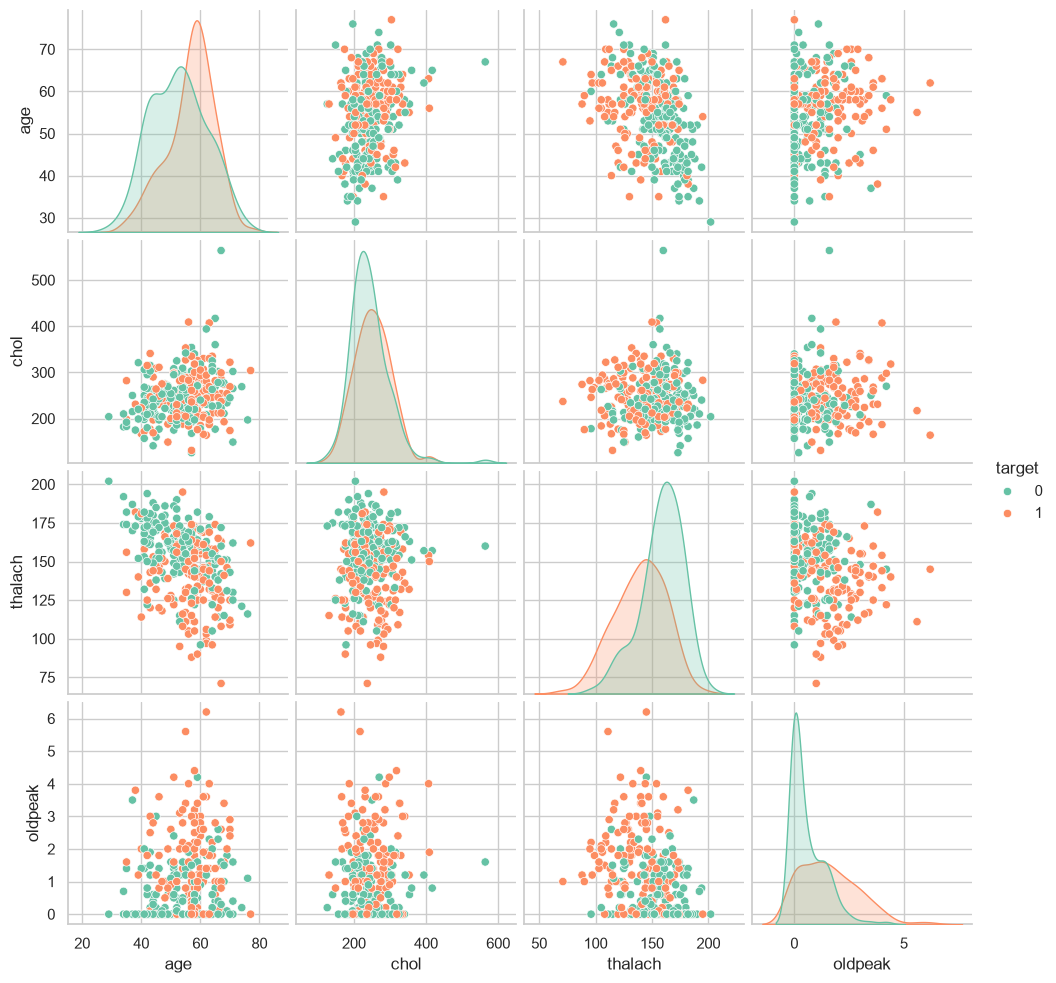

In [15]:
# Pairplot

selected_features = [
    "age",
    "chol",
    "thalach",
    "oldpeak",
    "target"
]

sns.pairplot(
    heart_df[selected_features],
    hue="target",
    palette="Set2"
)

plt.savefig("C:/Projects/Heart-Disease-MLOps/reports/figures/pairplot.png", dpi=300)

plt.show()

### Observation

The pairplot reveals the relationships among selected clinical features. While there is some overlap between the two target classes, variables such as **maximum heart rate** and **oldpeak** show noticeable differences between patients with and without heart disease.

# Scatter Plot Analysis

Scatter plots help visualize the relationship between two numerical variables and identify whether any separation exists between the target classes.

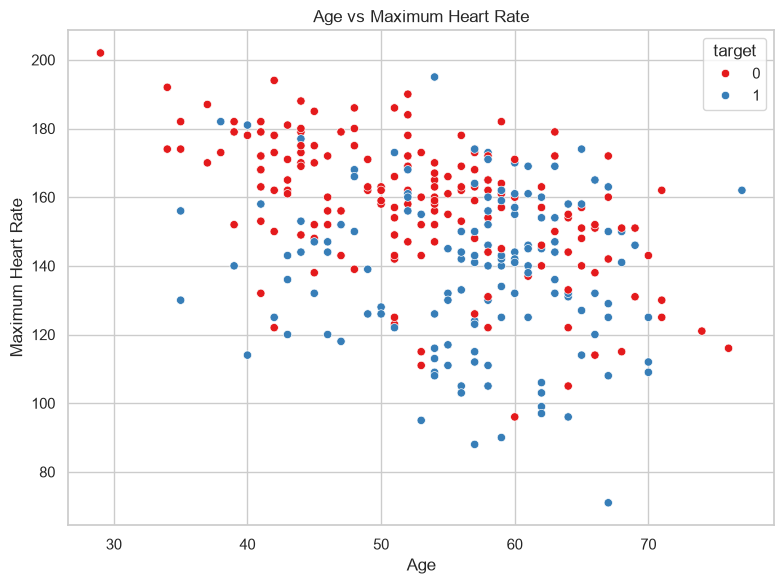

In [17]:
# Scatter Plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=heart_df,
    x="age",
    y="thalach",
    hue="target",
    palette="Set1"
)

plt.title("Age vs Maximum Heart Rate")

plt.xlabel("Age")

plt.ylabel("Maximum Heart Rate")

plt.tight_layout()

plt.savefig("C:/Projects/Heart-Disease-MLOps/reports/figures/scatterplot_age_thalach.png", dpi=300)

plt.show()

### Observation

The scatter plot shows that younger patients generally achieve higher maximum heart rates during exercise. Patients with heart disease appear across different age groups, indicating that age alone is insufficient for predicting the condition.

# Violin Plot Analysis

Violin plots combine the characteristics of boxplots and density plots to compare feature distributions between patients with and without heart disease.

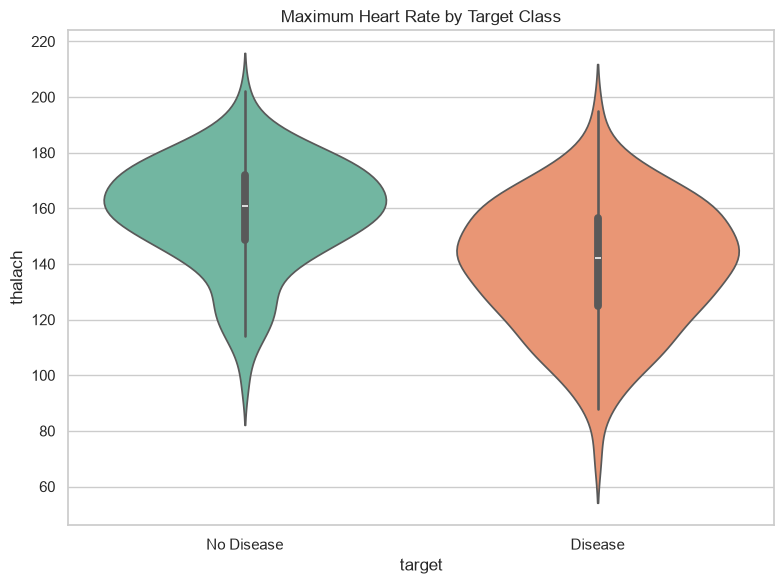

In [18]:
# Violin Plot

plt.figure(figsize=(8,6))

sns.violinplot(
    data=heart_df,
    x="target",
    y="thalach",
    palette="Set2"
)

plt.xticks([0,1],["No Disease","Disease"])

plt.title("Maximum Heart Rate by Target Class")

plt.tight_layout()

plt.savefig("C:/Projects/Heart-Disease-MLOps/reports/figures/violinplot_thalach.png", dpi=300)

plt.show()

### Observation

The violin plot indicates that patients without heart disease generally have higher maximum heart rates compared to patients diagnosed with heart disease. The distribution also highlights the variability within each class.

# Exploratory Data Analysis Summary

The exploratory data analysis provided valuable insights into the Heart Disease dataset.

### Key Findings

- The dataset is relatively balanced between patients with and without heart disease.
- Missing values were identified in the `ca` and `thal` columns and successfully handled using median imputation.
- Most numerical variables exhibit reasonable distributions, although some features contain outliers.
- Correlation analysis indicates that features such as chest pain, maximum heart rate, exercise-induced angina, and oldpeak have meaningful relationships with the target variable.
- Pairplots, scatter plots, and violin plots demonstrate that multiple clinical features contribute to distinguishing between patients with and without heart disease.

The cleaned dataset is now ready for feature engineering, model training, and evaluation.